In [8]:
# MULTILINGUAL RENDERER - Production ready
import os
import tempfile
from pathlib import Path
import subprocess
from PIL import Image as PILImage

import cairo

import gi
gi.require_version("Pango", "1.0")
gi.require_version("PangoCairo", "1.0")

from gi.repository import Pango, PangoCairo  # type: ignore


class MultilingualPangoRenderer:
    """
    Render multilingual text (Hindi, Gujarati, Marathi, etc.) from custom fonts directory.
    No system font installation needed!
    """
    
    def __init__(self, fonts_dir: str | Path):
        """Initialize with custom fonts directory and configure Pango/fontconfig."""
        self.fonts_dir = Path(fonts_dir).resolve()
        self._setup_fontconfig()
    
    def _setup_fontconfig(self):
        """Configure Pango to use fonts from custom directory."""
        # Create fontconfig that includes custom directory
        fontconfig_xml = f"""<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>
  <dir>{self.fonts_dir}</dir>
  <cachedir>~/.cache/fontconfig</cachedir>
</fontconfig>
"""
        
        # Write to temp file
        temp_fc = Path("/tmp") / "fontconfig_multilingual.xml"
        temp_fc.write_text(fontconfig_xml)
        
        # Set environment
        os.environ['FONTCONFIG_FILE'] = str(temp_fc)
        os.environ['FONTCONFIG_PATH'] = str(self.fonts_dir)
        
        # Update cache
        os.system(f"fc-cache -fv {self.fonts_dir} 2>/dev/null")
        print(f"✓ Configured Pango for: {self.fonts_dir}")
    
    def list_fonts(self):
        """List available fonts with their families."""
        from fontTools.ttLib import TTFont
        fonts_info = {}
        for ttf_file in self.fonts_dir.glob("*.ttf"):
            try:
                font = TTFont(str(ttf_file))
                family = font['name'].getName(1, 3, 1).toUnicode() #type: ignore
                fonts_info[ttf_file.name] = family
            except:
                fonts_info[ttf_file.name] = "Unknown"
        return fonts_info
    
    def render_multilingual(
        self,
        texts: dict,  # {"language": "text", ...} e.g., {"gujarati": "સેટ", "hindi": "सेट"}
        font_family_map: dict,  # {"language": "font_family"} e.g., {"gujarati": "Noto Sans Gujarati"}
        font_size: int = 30,
        width: int = 800,
        height: int = 400,
        bg_color: str = "white",
        text_color: str = "black",
        output_path: str | None = None,
        spacing: int = 20,  # Vertical spacing between lines
    ) -> None:
        """
        Render multiple language texts one below the other.
        
        Args:
            texts: Dict mapping language names to text strings
            font_family_map: Dict mapping language names to font family names
            font_size: Font size in points
            width, height: Canvas dimensions
            bg_color, text_color: Colors
            output_path: File to save to
            spacing: Vertical spacing between lines
        """
        
        # Create canvas
        surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, width, height)
        ctx = cairo.Context(surface)
        
        # Set background
        if bg_color == "white":
            ctx.set_source_rgb(1, 1, 1)
        else:
            ctx.set_source_rgb(0, 0, 0)
        ctx.paint()
        
        # Set text color
        if text_color == "black":
            ctx.set_source_rgb(0, 0, 0)
        else:
            ctx.set_source_rgb(1, 1, 1)
        
        # Render each language text
        y_offset = 50  # Starting Y position
        
        for language, text in texts.items():
            font_family = font_family_map.get(language, "Monospace")
            
            layout = PangoCairo.create_layout(ctx)
            layout.set_text(text, -1)
            
            # Set font
            font_desc = Pango.FontDescription()
            font_desc.set_family(font_family)
            font_desc.set_size(font_size * 1024)
            layout.set_font_description(font_desc)
            
            # Get text dimensions
            ink_rect, logical_rect = layout.get_pixel_extents()
            text_height = logical_rect.height
            
            # Center horizontally
            x = (width - logical_rect.width) / 2
            
            # Move to position
            ctx.move_to(x, y_offset)
            
            # Draw
            PangoCairo.show_layout(ctx, layout)
            
            # Add language label and move to next line
            y_offset += text_height + spacing
            print(f"  ✓ {language}: {text}")
        
        # Save
        surface.write_to_png(output_path or "multilingual_output.png")
        print(f"\n✓ Rendered to {output_path or 'multilingual_output.png'}")
    
    def render_mixed_text(
        self,
        text: str,
        font_families: list[str] = None,   # Font family fallback order
        font_size: int = 30,
        width: int = 800,
        height: int = 300,
        output_path: str | None = None,
    ) -> None:
        """
        Render mixed-script text with font fallback.
        Pango automatically selects appropriate font for each character.
        """
        
        if font_families is None:
            font_families = [
                "Noto Sans Gujarati",
                "Noto Sans Devanagari",
                "Noto Sans",
                "Monospace"
            ]
        
        surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, width, height)
        ctx = cairo.Context(surface)
        ctx.set_source_rgb(1, 1, 1)
        ctx.paint()
        
        layout = PangoCairo.create_layout(ctx)
        layout.set_text(text, -1)
        
        # Set font with fallback list
        font_desc = Pango.FontDescription()
        font_desc.set_family(", ".join(font_families))
        font_desc.set_size(font_size * 1024)
        layout.set_font_description(font_desc)
        
        # Center
        ink_rect, logical_rect = layout.get_pixel_extents()
        x = (width - logical_rect.width) / 2
        y = (height - logical_rect.height) / 2
        
        ctx.move_to(x, y)
        ctx.set_source_rgb(0, 0, 0)
        PangoCairo.show_layout(ctx, layout)
        
        surface.write_to_png(output_path or "mixed_text_output.png")
        print(f"✓ Rendered mixed text to {output_path or 'mixed_text_output.png'}")

# Initialize renderer
ml_renderer = MultilingualPangoRenderer("./fonts")

# Show available fonts
print("\nAvailable fonts:")
fonts = ml_renderer.list_fonts()
for filename, family in list(fonts.items())[:8]:
    print(f"  {filename:45} → {family}")


Font directories:
	/home/akhil/Invitation_research/fonts
/home/akhil/Invitation_research/fonts: caching, new cache contents: 18 fonts, 0 dirs
/home/akhil/.cache/fontconfig: cleaning cache directory
fc-cache: succeeded
✓ Configured Pango for: /home/akhil/Invitation_research/fonts

Available fonts:
  EKLG-48 Rinesh.ttf                            → EKLG-48 Rinesh
  GreatVibes-Regular.ttf                        → Great Vibes
  EKLG-38 Rinesh.ttf                            → EKLG-38 Rinesh
  AMS Kashi Regular.ttf                         → AMS Kashi
  TiroDevanagariHindi-Regular.ttf               → Tiro Devanagari Hindi
  PlayfairDisplay-Regular.ttf                   → Playfair Display
  NotoSansGujarati-VariableFont_wdth,wght.ttf   → Noto Sans Gujarati
  AnekGujarati_Expanded-Regular.ttf             → Anek Gujarati Expanded


EXAMPLE 1: Multilingual Invitation (Hindi, Gujarati, English)
  ✓ English: You are invited to
  ✓ Hindi: आप को आमंत्रित किया जाता है
  ✓ Gujarati: તમને આમંત્રણ આપવામાં આવે છે

✓ Rendered to multilingual_invitation.png


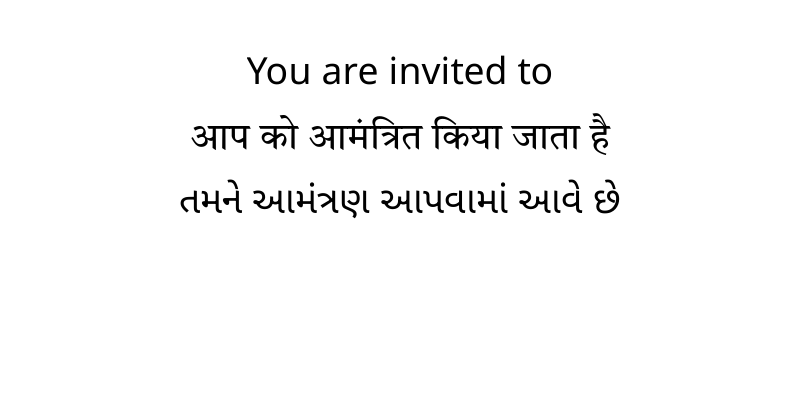

In [10]:
# EXAMPLE 1: Render multiple Indian languages
print("=" * 60)
print("EXAMPLE 1: Multilingual Invitation (Hindi, Gujarati, English)")
print("=" * 60)

ml_renderer.render_multilingual(
    texts={
        "English": "You are invited to",
        "Hindi": "आप को आमंत्रित किया जाता है",
        "Gujarati": "તમને આમંત્રણ આપવામાં આવે છે"
    },
    font_family_map={
        "English": "Noto Sans",
        "Hindi": "Tiro Devanagari Hindi",
        "Gujarati": "Noto Sans Gujarati"
    },
    font_size=28,
    width=800,
    height=400,
    output_path="multilingual_invitation.png"
)

# Display
from PIL import Image
img1 = Image.open("multilingual_invitation.png")
img1


EXAMPLE 2: Wedding Invitation (Gujarati + English)
  ✓ Title (Gujarati): લગ્ન સમારંભ
  ✓ Title (English): Wedding Ceremony
  ✓ Date (Gujarati): તારીખ: ૧૫ મે ૨૦૨૬
  ✓ Date (English): Date: May 15, 2026

✓ Rendered to wedding_invitation.png


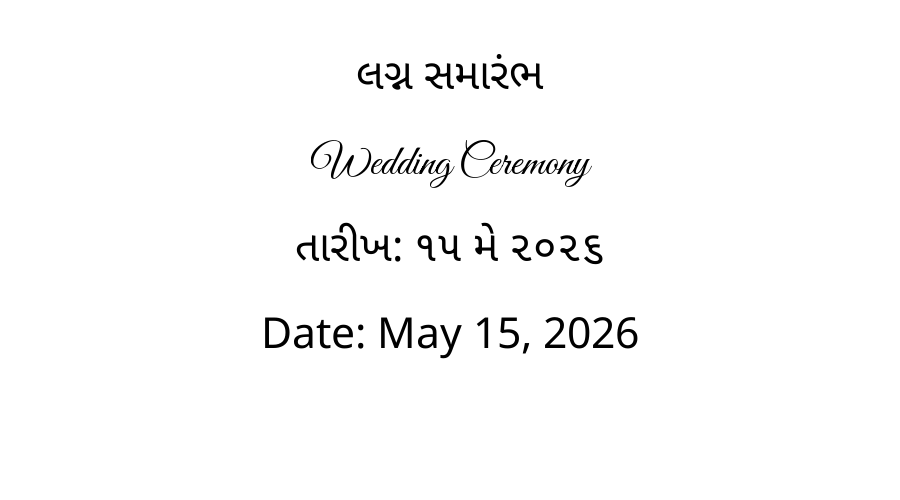

In [11]:
# EXAMPLE 2: Gujarati + English (Wedding Invitation style)
print("\n" + "=" * 60)
print("EXAMPLE 2: Wedding Invitation (Gujarati + English)")
print("=" * 60)

ml_renderer.render_multilingual(
    texts={
        "Title (Gujarati)": "લગ્ન સમારંભ",
        "Title (English)": "Wedding Ceremony",
        "Date (Gujarati)": "તારીખ: ૧૫ મે ૨૦૨૬",
        "Date (English)": "Date: May 15, 2026",
    },
    font_family_map={
        "Title (Gujarati)": "Noto Sans Gujarati",
        "Title (English)": "Great Vibes",
        "Date (Gujarati)": "Noto Sans Gujarati",
        "Date (English)": "Noto Sans",
    },
    font_size=32,
    width=900,
    height=500,
    spacing=30,
    output_path="wedding_invitation.png"
)

img2 = Image.open("wedding_invitation.png")
img2